<a href="https://colab.research.google.com/github/serivan/mldmlab/blob/master/ML4ClimateChange/notebooks/02_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis & Machine Learning

This notebook provides a skeleton for loading data, processing it, running ML models, and visualizing results.

In [ ]:
!pip install cartopy

## 1. Load Data

CDS returns either a zip containing one file for each variable or one file with all variables together, depending on the dataset

In [ ]:
import os
import zipfile
import urllib.request

DATA_DIR = "./data"
ZIP_FILE = os.path.join(DATA_DIR, "era5_italy_daily_sample.zip")

URL = "https://raw.githubusercontent.com/serivan/mldmlab/master/ML4ClimateChange/data/era5_italy_daily_sample.zip"

os.makedirs(DATA_DIR, exist_ok=True)

# Scarica il file se non è già presente
if not os.path.exists(ZIP_FILE):
    print("Download del file...")
    urllib.request.urlretrieve(URL, ZIP_FILE)

temperature_data = None
surface_pressure_data = None
data_files = None

try:
    with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)
        extracted_files = zip_ref.namelist()

        print("File estratti:")
        for file in extracted_files:
            print(file)

            if "2m_temperature" in file:
                temperature_data = os.path.join(DATA_DIR, file)

            elif "surface_pressure" in file:
                surface_pressure_data = os.path.join(DATA_DIR, file)

except zipfile.BadZipFile:
    data_files = os.path.join(DATA_DIR, "era5_daily_sample.nc")

print("Temperature data:", temperature_data)
print("Surface pressure data:", surface_pressure_data)
print("Data files:", data_files)

File estratti:
2m_temperature_0_daily-mean.nc
surface_pressure_0_daily-mean.nc
Temperature data: ./data/2m_temperature_0_daily-mean.nc
Surface pressure data: ./data/surface_pressure_0_daily-mean.nc
Data files: None


In [ ]:
print("Temperature data:", temperature_data)

Temperature data: ./data/2m_temperature_0_daily-mean.nc


In [ ]:
import zipfile

# The downloaded file might be a zip archive depending on the CDS API response
try:
    with zipfile.ZipFile('../data/era5_italy_daily_sample.zip', 'r') as zip_ref:
        zip_ref.extractall('../data/')
        extracted_files = zip_ref.namelist()
        #find temperature file and surface pressure file
        for file in extracted_files:
            if '2m_temperature' in file:
                temperature_data = f'../data/{file}'
                continue
            elif 'surface_pressure' in file:
                surface_pressure_data = f'../data/{file}'
                continue
except zipfile.BadZipFile:
    data_files = '../data/era5_daily_sample.nc'

## 2. Preprocessing
Handle missing values, feature engineering.

In [ ]:
import xarray as xr
# Load the datasets
ds_temp = xr.open_dataset(temperature_data)

#Inspecting the structure
print("--- Temperature Data Info ---")
ds_temp.info()


--- Temperature Data Info ---
xarray.Dataset {
dimensions:
	valid_time = 31 ;
	latitude = 116 ;
	longitude = 126 ;

variables:
	float32 t2m(valid_time, latitude, longitude) ;
		t2m:GRIB_paramId = 167 ;
		t2m:GRIB_dataType = fc ;
		t2m:GRIB_numberOfPoints = 14616 ;
		t2m:GRIB_typeOfLevel = surface ;
		t2m:GRIB_stepUnits = 1 ;
		t2m:GRIB_stepType = instant ;
		t2m:GRIB_gridType = regular_ll ;
		t2m:GRIB_uvRelativeToGrid = 0 ;
		t2m:GRIB_NV = 0 ;
		t2m:GRIB_Nx = 126 ;
		t2m:GRIB_Ny = 116 ;
		t2m:GRIB_cfName = unknown ;
		t2m:GRIB_cfVarName = t2m ;
		t2m:GRIB_gridDefinitionDescription = Latitude/Longitude Grid ;
		t2m:GRIB_iDirectionIncrementInDegrees = 0.1 ;
		t2m:GRIB_iScansNegatively = 0 ;
		t2m:GRIB_jDirectionIncrementInDegrees = 0.1 ;
		t2m:GRIB_jPointsAreConsecutive = 0 ;
		t2m:GRIB_jScansPositively = 0 ;
		t2m:GRIB_latitudeOfFirstGridPointInDegrees = 47.5 ;
		t2m:GRIB_latitudeOfLastGridPointInDegrees = 36.0 ;
		t2m:GRIB_longitudeOfFirstGridPointInDegrees = 6.5 ;
		t2m:GRIB_longitude

In [ ]:
ds_sp = xr.open_dataset(surface_pressure_data, engine="h5netcdf")
print("--- Surface Pressure Data Info ---")
ds_sp.info()

--- Surface Pressure Data Info ---
xarray.Dataset {
dimensions:
	valid_time = 31 ;
	latitude = 116 ;
	longitude = 126 ;

variables:
	float32 sp(valid_time, latitude, longitude) ;
		sp:GRIB_paramId = 134 ;
		sp:GRIB_dataType = fc ;
		sp:GRIB_numberOfPoints = 14616 ;
		sp:GRIB_typeOfLevel = surface ;
		sp:GRIB_stepUnits = 1 ;
		sp:GRIB_stepType = instant ;
		sp:GRIB_gridType = regular_ll ;
		sp:GRIB_uvRelativeToGrid = 0 ;
		sp:GRIB_NV = 0 ;
		sp:GRIB_Nx = 126 ;
		sp:GRIB_Ny = 116 ;
		sp:GRIB_cfName = surface_air_pressure ;
		sp:GRIB_cfVarName = sp ;
		sp:GRIB_gridDefinitionDescription = Latitude/Longitude Grid ;
		sp:GRIB_iDirectionIncrementInDegrees = 0.1 ;
		sp:GRIB_iScansNegatively = 0 ;
		sp:GRIB_jDirectionIncrementInDegrees = 0.1 ;
		sp:GRIB_jPointsAreConsecutive = 0 ;
		sp:GRIB_jScansPositively = 0 ;
		sp:GRIB_latitudeOfFirstGridPointInDegrees = 47.5 ;
		sp:GRIB_latitudeOfLastGridPointInDegrees = 36.0 ;
		sp:GRIB_longitudeOfFirstGridPointInDegrees = 6.5 ;
		sp:GRIB_longitudeOfLastG

In [ ]:
def preprocess_era5(ds):
    rename_dict = {}
    if 'latitude' in ds.dims: rename_dict['latitude'] = 'lat'
    if 'longitude' in ds.dims: rename_dict['longitude'] = 'lon'
    if 'valid_time' in ds.dims: rename_dict['valid_time'] = 'time'
    if rename_dict:
        ds = ds.rename(rename_dict)

    return ds

# Apply structural preprocessing
ds_temp = preprocess_era5(ds_temp)
ds_sp = preprocess_era5(ds_sp)

# Unit Conversions
# Temperature: Kelvin to Celsius
if 't2m' in ds_temp.variables:
    # Save original attributes (like long_name) so they aren't lost during math operations
    attrs = ds_temp['t2m'].attrs
    ds_temp['t2m'] = ds_temp['t2m'] - 273.15
    ds_temp['t2m'].attrs = attrs
    ds_temp['t2m'].attrs['units'] = '°C'

# Surface Pressure: Pascals to hPa
if 'sp' in ds_sp.variables:
    attrs = ds_sp['sp'].attrs
    ds_sp['sp'] = ds_sp['sp'] / 100.0
    ds_sp['sp'].attrs = attrs
    ds_sp['sp'].attrs['units'] = 'hPa'

print("Preprocessing complete. Datasets are ready for visualization.")

Preprocessing complete. Datasets are ready for visualization.


## 3. Visualization

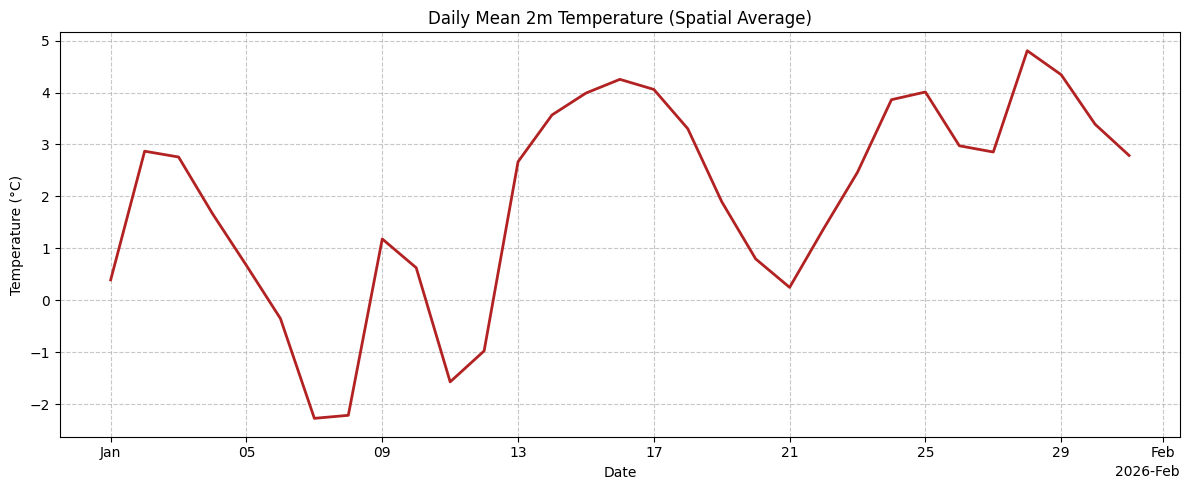

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Load the dataset using the path from your extraction script
ds = ds_temp  # Use the preprocessed temperature dataset

# ==========================================
# Plot 1: Timeseries of Spatial Average
# ==========================================
plt.figure(figsize=(12, 5))

# Average over both spatial dimensions (latitude and longitude)
spatial_mean_temp = ds['t2m'].mean(dim=["lat", "lon"])

# Plot the timeseries using xarray's built-in plotting
spatial_mean_temp.plot.line(color='firebrick', linewidth=2)

plt.title('Daily Mean 2m Temperature (Spatial Average)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the first plot
plt.show()


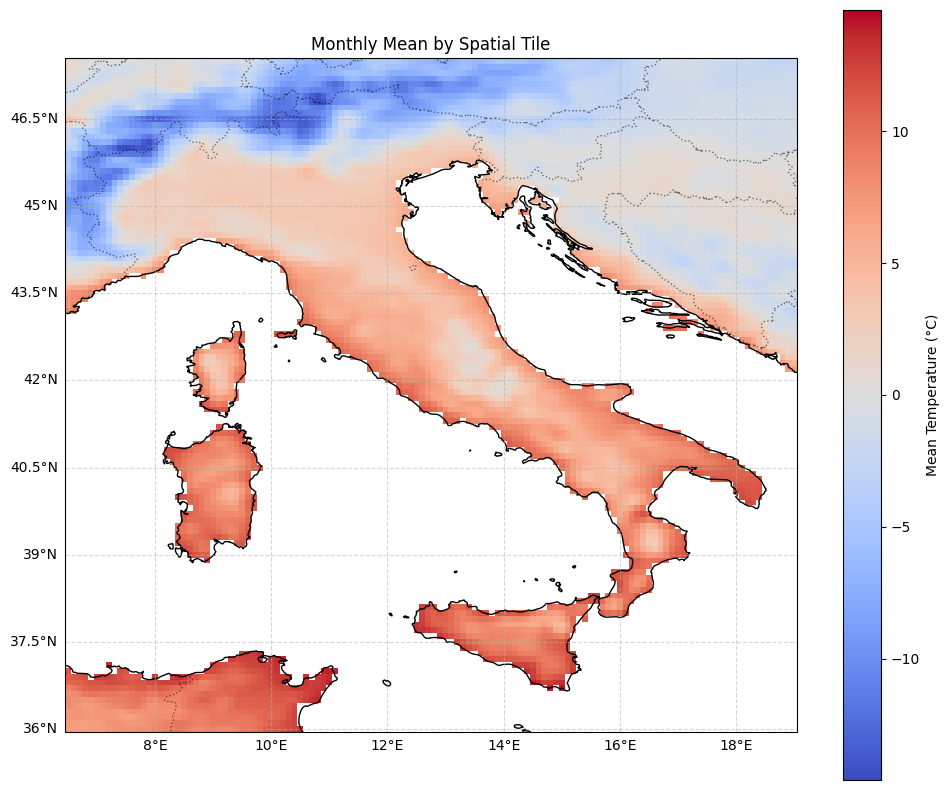

In [ ]:

# ==========================================
# Plot 2: Spatial Map of Temporal Mean
# ==========================================
plt.figure(figsize=(10, 8))

# Average over the time dimension to get the monthly mean for each pixel
temporal_mean_temp = ds['t2m'].mean(dim='time')

# Set up the map projection using Cartopy
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the 2D spatial data
temporal_mean_temp.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm', # A good colormap for temperatures
    cbar_kwargs={'label': 'Mean Temperature (°C)'}
)

# Add geographical features to make it recognizable
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)

# Optional: Add gridlines (lat/lon)
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.title('Monthly Mean by Spatial Tile')
plt.tight_layout()

# Show the second plot
plt.show()

# Clean up by closing the dataset when finished
ds.close()

## 4. Machine Learning Tasks (e.g. clustering)

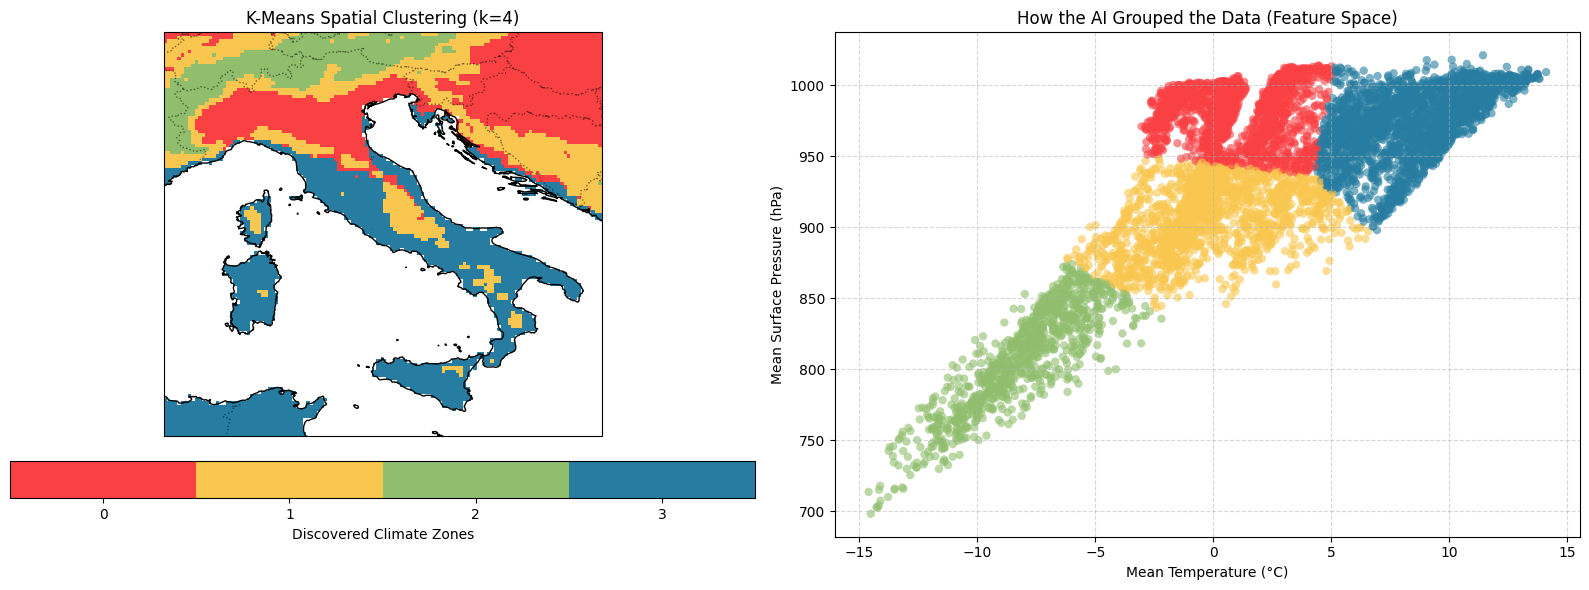

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

# ==========================================
# 1. Data Wrangling & Preprocessing
# ==========================================
# Extract the 2D temporal mean maps (from previous steps)
temp_mean = ds_temp['t2m'].mean(dim='time')
sp_mean = ds_sp['sp'].mean(dim='time')

# Flatten the 2D arrays into 1D lists
temp_flat = temp_mean.values.flatten()
sp_flat = sp_mean.values.flatten()

# Create a boolean mask to filter out any NaN values (missing data)
valid_mask = ~np.isnan(temp_flat) & ~np.isnan(sp_flat)

# Stack the two variables together into a table of features (Rows = Pixels, Cols = [Temp, Pressure])
# This is the exact format scikit-learn requires for X
X_raw = np.column_stack((temp_flat[valid_mask], sp_flat[valid_mask]))

# !Scale the features so Pressure doesn't overpower Temperature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# ==========================================
# 2. Machine Learning: K-Means Clustering
# ==========================================
# We will ask the model to find 4 distinct climate zones
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Train the model and get the cluster assignments (0, 1, 2, or 3 for each pixel)
cluster_labels = kmeans.fit_predict(X_scaled)

# ==========================================
# 3. Reconstruct the Spatial Map
# ==========================================
# Create an empty array filled with NaNs that matches the original flattened map size
full_labels_flat = np.full(temp_flat.shape, np.nan)

# Put the cluster labels back into the valid pixel locations
full_labels_flat[valid_mask] = cluster_labels

# Reshape the 1D list back into the 2D geographical grid (Lat x Lon)
cluster_map_2d = full_labels_flat.reshape(temp_mean.shape)

# ==========================================
# 4. Visualization
# ==========================================
# We will create a 1x2 figure to show BOTH the geographical map and the ML feature space
fig = plt.figure(figsize=(16, 6))

# Define a custom color palette for our 4 distinct zones
colors = ['#f94144', '#f9c74f', '#90be6d', '#277da1', "#B900FC"][:n_clusters]  # Use only as many colors as clusters
cmap = ListedColormap(colors)

# --- Subplot 1: The Geographical Map ---
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.add_feature(cfeature.COASTLINE, linewidth=1)
ax1.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)

# Plot the categorical cluster map
mesh = ax1.pcolormesh(
    temp_mean.lon, temp_mean.lat, cluster_map_2d,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    vmin=-0.5, vmax=n_clusters-0.5 # Centers the colors on the integers 0, 1, 2, 3
)

# Add a colorbar
cbar = plt.colorbar(mesh, ax=ax1, orientation='horizontal', pad=0.05, ticks=range(n_clusters))
cbar.set_label('Discovered Climate Zones')
ax1.set_title(f'K-Means Spatial Clustering (k={n_clusters})')

# --- Subplot 2: The Feature Space (Scatter Plot) ---
ax2 = fig.add_subplot(1, 2, 2)

# Scatter plot of Temp vs Pressure, colored by the cluster the ML assigned them to
scatter = ax2.scatter(X_raw[:, 0], X_raw[:, 1], c=cluster_labels, cmap=cmap, alpha=0.6, edgecolors='none')

ax2.set_title('How the AI Grouped the Data (Feature Space)')
ax2.set_xlabel('Mean Temperature (°C)')
ax2.set_ylabel('Mean Surface Pressure (hPa)')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()